# Setup

## Imports

In [1]:
import pandas as pd
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from src.preprocessing import (
    filter_low_magnitude_genes,
    filter_high_apoptosis_cells,
    normalize_by_library_size,
    log_transform,
    normalize_data_with_pearson,
    genes,
    filter_doublets
)
from src.visualization import (
    plot_gene_magnitude_distribution,
    plot_normalization_comparison,
    plot_log_transform_comparison,
    plot_pearson_diagnostic,
    plot_metric_distribution,
    calculate_gene_fraction,
)
from src.utils import extract_gene_subset, count_mouse_mt_genes, get_mouse_mt_genes

## Data Loading

In [3]:
from src.data_loading import load_csv_data

DATA_PATH = '../data/GSE57249/raw/mouse.embryo.GSE57249.count_matrix.csv.gz'
raw_data = load_csv_data(DATA_PATH)
raw_data = raw_data.T

raw_data.shape

(56, 48440)

# Gene Filtering

In [4]:
clean_data = filter_low_magnitude_genes(raw_data)

clean_data.head()

  • Dropped 45566 low-magnitude genes


,Gm2053,Gm6104,Gm37277,Gm2147,Gm15452,Gm22607,Snord87,1700047N06Rik,Gm26348,Gm5250,...,mt-Tr,mt-Th,mt-Ts2,mt-Tl2,mt-Nd5,mt-Nd6,mt-Te,mt-Cytb,mt-Tt,mt-Tp
GSM1377886,0,0,0,0,0,0,0,0,0,0,...,5414,3581,3059,5183,289964,74702,6899,188587,9406,8889
GSM1377866,0,0,0,0,0,0,0,0,0,543,...,1906,1159,1048,1846,198925,41347,2656,184766,6233,5562
GSM1377897,0,0,0,0,0,0,1431,0,0,0,...,4790,2298,2583,3655,284837,68139,5014,193773,8663,9425
GSM1377898,0,0,0,0,0,0,2158,0,0,0,...,5193,2544,2898,3521,273392,71442,6398,193129,8028,9621
GSM1377870,0,0,0,0,0,0,820,0,0,3758,...,5777,2666,2494,3738,266610,61952,5270,197220,6931,7324


# Quality Control (Cell Filtering)

## Mitochondrial

In [5]:
print("Mitochondrial genes:", count_mouse_mt_genes(clean_data))

Mitochondrial genes: 26


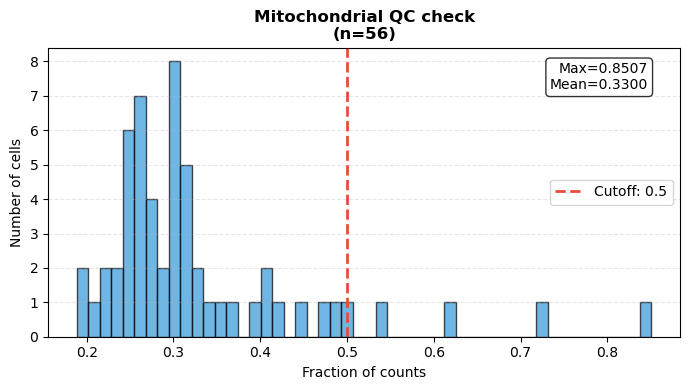

In [6]:
mito_fractions = calculate_gene_fraction(clean_data, get_mouse_mt_genes(clean_data))
plot_metric_distribution(mito_fractions, title="Mitochondrial QC check", cutoff=0.5)

## Apoptosis

In [7]:
apoptosis_data = extract_gene_subset(clean_data, genes.MOUSE_APOPTOSIS_GENES, "Apoptosis")

Apoptosis: Matched 0 of 161 reference genes.


## rRNA

In [8]:
rrna_data = extract_gene_subset(clean_data, genes.MOUSE_RRNA_GENES, "rRNA")

rRNA: Matched 8 of 356 reference genes.


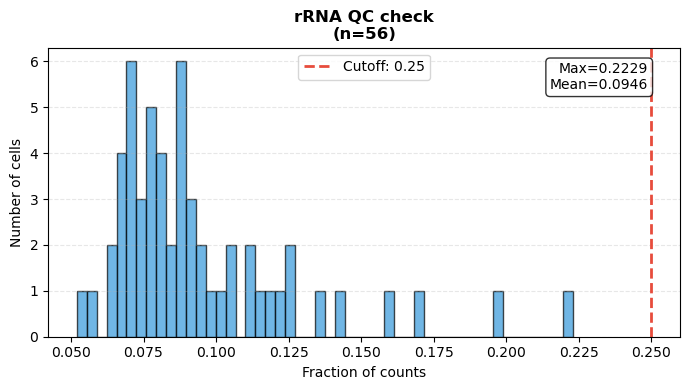

In [9]:
rrna_fractions = calculate_gene_fraction(clean_data, genes.MOUSE_RRNA_GENES)
plot_metric_distribution(rrna_fractions, title="rRNA QC check", cutoff=0.25)

## Doublets

If we run scrublet we get this error: "ValueError: n_components=30 must be between 1 and min(n_samples, n_features)=9 with svd_solver='arpack'". 56 cells are not enough for calculating doublets. 

# Normalization

## logCPM

### Normalize by library size

In [10]:
normalized_data = normalize_by_library_size(clean_data)

normalized_data.shape

  • Normalizing library size (rescale=1e+06)


(56, 2874)

### Log Transform

In [11]:
logged_data = log_transform(normalized_data)

logged_data.shape

  • Applying log transform (log1+x)


(56, 2874)

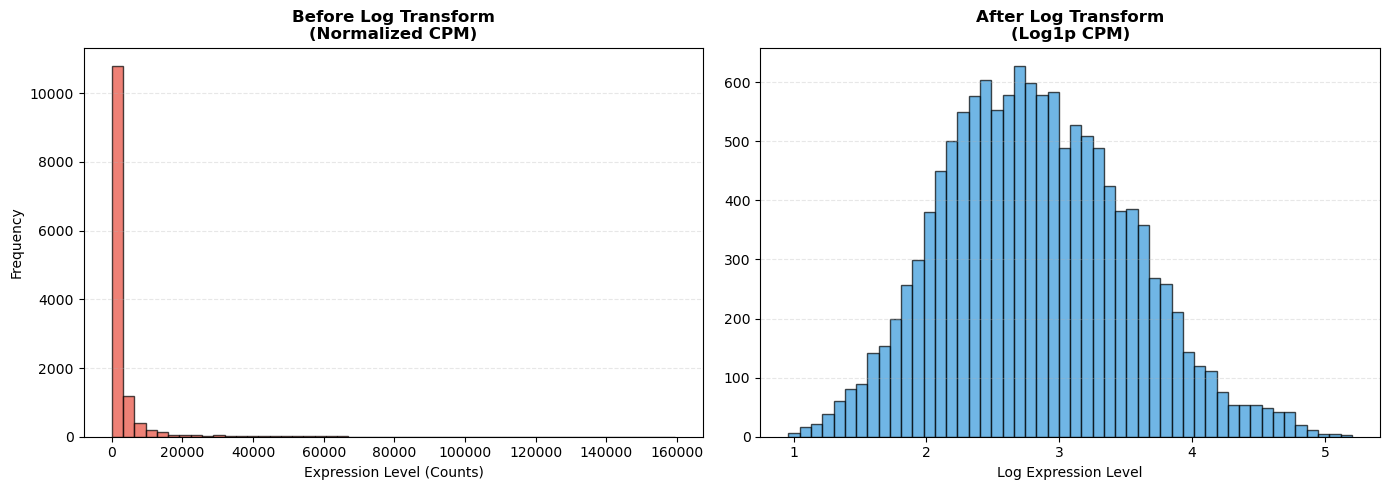

In [12]:
plot_log_transform_comparison(normalized_data, logged_data)

## Pearson residuals

In [13]:
pearsons_data = normalize_data_with_pearson(clean_data)

pearsons_data.shape

  • Computing residuals for 56 cells
  • Selecting top 3000 variable genes


/opt/anaconda3/envs/scrna-seq-clustering/lib/python3.14/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


ValueError: Length of values (2906) does not match length of index (2874)

In [ ]:
pearsons_data.head()